In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import matplotlib.cm as cm
import json
import matplotlib.ticker as ticker

%matplotlib notebook

In [10]:
def asymmetric_ticks(ax, major_len=12, minor_len=6, major_w=1.9, minor_w=1.6, labelsize=22):
    # Base axis: bottom & left OUT
    ax.minorticks_on()
    ax.tick_params(which='major', length=major_len, width=major_w, labelsize=labelsize,
                   direction='out', bottom=True, left=True, top=False, right=False)
    ax.tick_params(which='minor', length=minor_len, width=minor_w,
                   direction='out', bottom=True, left=True, top=False, right=False)

    # TOP axis (IN)
    axt = ax.twiny()
    axt.set_xscale(ax.get_xscale())             # keep same scale (log/linear)
    axt.set_xlim(ax.get_xlim())
    axt.minorticks_on()
    axt.tick_params(which='major', length=major_len, width=major_w,
                    direction='in', top=True, bottom=False, labeltop=False)
    axt.tick_params(which='minor', length=minor_len, width=minor_w,
                    direction='in', top=True, bottom=False)
    for s in ('left','right','bottom'):         # show only the top spine
        axt.spines[s].set_visible(False)

    # RIGHT axis (IN)
    axr = ax.twinx()
    axr.set_yscale(ax.get_yscale())
    axr.set_ylim(ax.get_ylim())
    axr.minorticks_on()
    axr.tick_params(which='major', length=major_len, width=major_w,
                    direction='in', right=True, left=False, labelright=False)
    axr.tick_params(which='minor', length=minor_len, width=minor_w,
                    direction='in', right=True, left=False)
    for s in ('left','top','bottom'):           # show only the right spine
        axr.spines[s].set_visible(False)

    return axt, axr

In [7]:
# Define the path to the configuration file
config_path = Path("/Users/eriklamb/Documents/Python/Projects/XPCS/configs/"+"NPS_results_config.json")
figure_path = '/Users/eriklamb/Documents/Publications/NPS_Petra/Figures/'


# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)
    #json_str = json.loads(jsonString, strict=False)


#T = np.array([298,305,325,365,385,405,350])
T = np.array([298,305,325,345,365,385,405,350])

best_ind = np.array([0,0,0,0,0,0,0,4])

TT=298

In [22]:
file = Path(config.get(f"{TT}"))
    #Load file
with h5py.File(file, 'r') as DATA:
    g2s = DATA['XPCS/G2_Results'][:]
    g2_errs = DATA['XPCS/G2_error'][:]
    delays = DATA['XPCS/delays'][:]
    dQ = DATA['XPCS/dQ'][:]
    As = DATA['XPCS/As'][:][0]
    aas = DATA['XPCS/aas'][:][0]

   # Cs = DATA['XPCS/Cs'][:]
    taus = DATA['XPCS/taus'][:][:,:]
    betas = DATA['XPCS/betas'][:][:,:]
    taus_err = DATA['XPCS/taus_err'][:][0,:]
    betas_err = DATA['XPCS/betas_err'][:][0,:]

    #TwoTime
    TwoTime = DATA['XPCS/TwoTime'][:]
    #print(TwoTime.shape)
    TwoTime_extent = DATA['XPCS/TwoTime_extent'][:]

In [23]:
taus.shape

(10, 2)

<IPython.core.display.Javascript object>


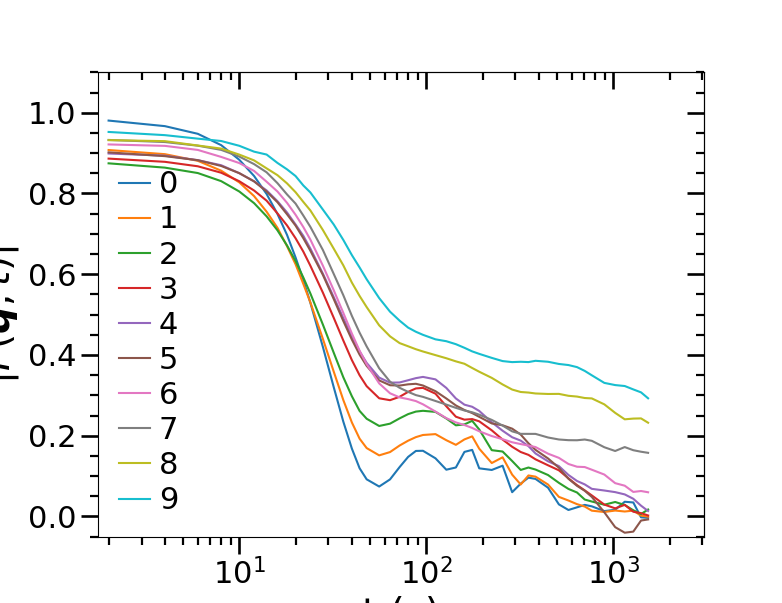

In [30]:
fig,ax=plt.subplots()


#print(As)
truncs = -35
# Fit
if TT==385:
    truncs = -7
if TT==405:
    truncs = -9
if TT==350:
    truncs = -1   #-16
if TT==365:
    truncs = -25
if TT==298:
    truncs = -25
if TT==305:
    truncs = -25
    
    
for i,g2 in enumerate(g2s):
    
    popt, pcov = curve_fit(g2_exp, delays[0,:truncs],g2[:truncs], p0=[As,taus[i,0],betas[i,0]])
    
    
    if TT==350:
        ax.semilogx(delays[0,:],((g2[:]-1)/popt[0])[:],marker_list[i],markersize=8,color=color_list[i],label=f'{T[i]} K - Cooling')
    else:
        ax.semilogx(delays[0,:],((g2[:]-1)/popt[0])[:],markersize=8,label=f'{i}')
    #ax.errorbar(delays[0,:],((g2[best_ind[i],:]-1)/popt[0])[:], yerr=g2_errs[best_ind[i],:],fmt='none',capsize=2,color=color_list[i])
    #ax.semilogx(delays[0,:],((g2_two_tau(delays[0,:],*popt)-1)/popt[0])[:],'-',color=color_list[i])
    #ax.semilogx(delays[0,:],((g2_exp(delays[0,:],*popt)-1)/popt[0])[:],'-')
    ax.set_xlim(1.75, 3050)
    #ax.legend(loc='lower left',fontsize=18)
    ax.set_ylim(bottom=-0.05)  # sets the lower limit to 0
    ax.set_ylim(top=1.1)  # sets the upper limit to 1.1

    leg = ax.legend(frameon=False,          # remove box
            handletextpad=0.3,      # space between marker and text
            handlelength=1.0,       # length of legend handle
            labelspacing=0.2,       # vertical spacing between entries
            borderpad=0.2,          # padding inside the legend area
            fontsize=22,
            loc='lower left')       # or wherever you want

    
# --- sizes ---
ax.tick_params(which='major', length=7, width=1.6, labelsize=18)
ax.tick_params(which='minor', length=4, width=1.2)

ax.set_ylabel(r'$|F(\boldsymbol{q},t)|^2$', fontsize=28)
ax.set_xlabel('t (s)',fontsize=28)  

# ... your plotting loop adds lines/points to ax ...
# after plotting (and after set_xscale('log') etc.), call once:
axt, axr = asymmetric_ticks(ax)
plt.show()